In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [2]:
print('Running imports...')

import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
plt.style.use('robin')
# matplotlib.use('tkagg')
import seaborn as sns 
import matplotlib.ticker as mticker
from tqdm.notebook import tqdm
import cartopy.crs as ccrs

Running imports...


In [3]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker

def clean_map_ax(ax, boundaries=(-90, 50, 0, 90), gl=True):
    lon_min, lon_max , lat_min, lat_max = boundaries

    ax.coastlines( color='.5',linewidths=.3)
    # ax.set_extent((-60,60,0,80))
    ax.set_extent(boundaries, crs=ccrs.PlateCarree())
    
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    if gl:
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(-180,180,17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        
    longitudes = np.linspace(lon_min, lon_max, 100)
    latitudes = np.linspace(lat_min, lat_max,100)
    xx = list(longitudes)[::-1]+\
            [longitudes.min() for _ in range(latitudes.size)] + \
                list(longitudes)+\
                    [longitudes.max() for _ in range(latitudes.size)]
    yy = [latitudes.max() for _ in range(longitudes.size)] \
            + list(latitudes)[::-1]+\
                [latitudes.min() for _ in range(longitudes.size)]+ \
                    list(latitudes)[::-1]
    verts = np.array([xx, yy]).T
    circle = Path(verts)
    ax.set_boundary(circle, transform=ccrs.PlateCarree())

In [30]:
ds_main = xr.open_dataset('out_data/rosendal/u850_4conv_layer_attributions.nc')
ds_linus = xr.open_dataset('out_data/rosendal/4conv_layer_linus_style_attributions.nc')
ds_vit = xr.open_dataset('out_data/rosendal/ViT_patch4_attributions.nc')

ds_main['fields'] = ds_main.attributions/ds_main.sensitivity
ds = xr.concat([ds_main.assign_coords(model='CNNmaxpool'), ds_linus.assign_coords(model='CNNlinus'), ds_vit.assign_coords(model='ViT')], dim='model')
ds_common = ds[['attributions','sensitivity']].where(ds.attributions.max(['longitude','latitude','var_name', 'timestep']).count('model')==3, drop=True)

In [31]:
josh_prec = xr.open_dataset(f"/Data/gfi/users/jodor4442/ERA5land_precursors/patterns/standard_DJF_region14.nc")
josh1 = josh_prec[['u850','v850']].to_array('var_name').sel(lag=[-2,-1,0]).isel(index_val=1).interp_like(ds_main).rename(lag='timestep').assign_coords(timestep=[2,3,4])
josh_prec_3 = xr.open_dataset(f"/Data/gfi/users/jodor4442/U_reg_14_long_prec/standard_DJF_regionregion14.nc")
josh3 = josh_prec_3[['u850','v850']].to_array('var_name').sel(lag=[-3]).isel(index_val=1).interp_like(ds_main).rename(lag='timestep').assign_coords(timestep=[1])
josh = xr.concat([josh3, josh1], dim='timestep')


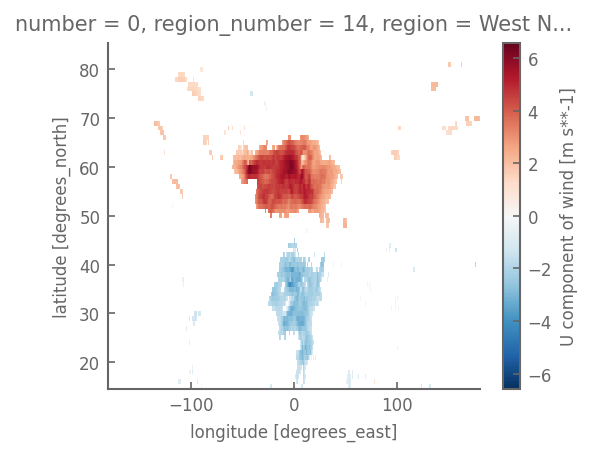

In [32]:
ds_mean = xr.open_dataset("/Data/gfi/users/jodor4442/U_reg_14_long_prec//mean_composites/DJF_region14.nc").sel(lag=-3).isel(index_val=1).u850
ds_sig = xr.open_dataset("/Data/gfi/users/jodor4442/U_reg_14_long_prec/sig_composites/DJF_region14.nc").sel(lag=-3).isel(index_val=1).u850
ds_mean.where(ds_sig==1).plot()

# Model peformance

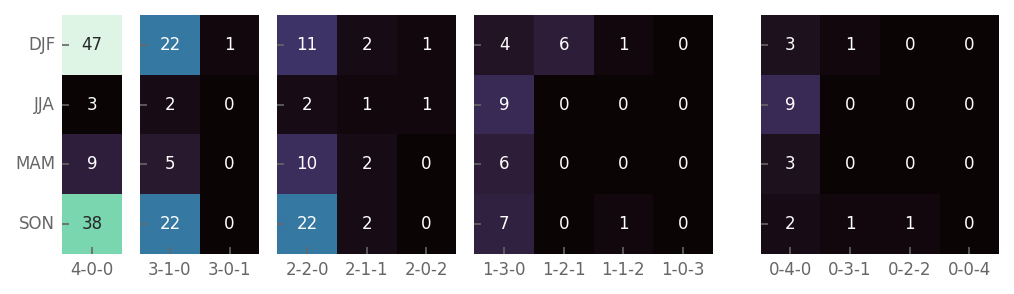

In [33]:
df_ = ds_main[['targets','preds']].to_dataframe().reset_index()
df_['season'] = df_.time.to_xarray().dt.season.to_series()
df_['prediction_time'] = df_.time + pd.Timedelta(1,'D')*df_.timestep
df__ = df_.pivot_table(index='prediction_time', columns = 'timestep', values=['targets','preds']).dropna()
df__['all_preds'] = df__.preds.astype(int).astype(str).sum(axis=1)
def count_row(row):
    counts = row.value_counts().to_dict()
    x0 = int(counts.get(0.0, 0))
    x1 = int(counts.get(1.0, 0))
    x2 = int(counts.get(2.0, 0))
    return f"{x2}-{x1}-{x0}"

df__['all_preds'] = df__.preds.apply(count_row, axis=1)

extreme_events_pred = df__.loc[df__.targets.max(axis=1)==2].all_preds.reset_index()
extreme_events_pred['season'] = pd.Series(extreme_events_pred.prediction_time).to_xarray().dt.season.to_series()
df_plot = extreme_events_pred.groupby(['all_preds','season']).count().prediction_time.unstack().sort_index().fillna(0)
df_plot.loc['0-0-4'] = [0,0,0,0]
df_plot.loc['1-0-3'] = [0,0,0,0]
df_plot= df_plot.sort_index()[::-1].T

fig, axs = plt.subplots(1,5, sharey=True, width_ratios=[1,2,3,4,5], figsize=(7,2))
sns.heatmap(df_plot.iloc[:,:1], square=True, cbar=False, ax=axs[0], vmax=45, annot=True, fmt='.0f', cmap='mako')
sns.heatmap(df_plot.iloc[:,1:3], square=True, cbar=False, ax=axs[1], vmax=45, annot=True, fmt='.0f', cmap='mako')
sns.heatmap(df_plot.iloc[:,3:6], square=True, cbar=False, ax=axs[2], vmax=45, annot=True, fmt='.0f', cmap='mako')
sns.heatmap(df_plot.iloc[:,6:10], square=True, cbar=False, ax=axs[3], vmax=45, annot=True, fmt='.0f', cmap='mako')
sns.heatmap(df_plot.iloc[:,10:], square=True, cbar=False, ax=axs[4], vmax=45, annot=True, fmt='.0f', cmap='mako')
for ax in axs:
    ax.set(ylabel='',xlabel='')
    ax.tick_params(rotation=0)
plt.tight_layout()
plt.savefig('plots/rosendal/Predictions_per_event.pdf')

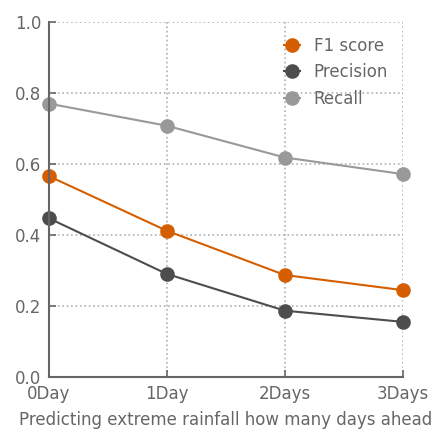

In [34]:
# df_
# df_.groupby(['time'])
TP = ((ds_main.targets==ds_main.preds)&(ds_main.targets==2)).sum('time')
prec = TP/(ds_main.preds==2).sum('time')
recall = TP/(ds_main.targets==2).sum('time')
f1 = 2*(prec*recall)/(prec+recall)

df_ = f1.rename('f1').to_series().reset_index()

# sns.lineplot(df_, x='timestep', y='f1', hue='n_conv_layers', palette='colorblind', marker='o')

fig, ax = plt.subplots(figsize=(3,3))
f1.plot(ax=ax, marker='o', label='F1 score', clip_on=False, color='C3')
prec.plot(ax=ax, marker='o', label='Precision', clip_on=False, color='.3')
recall.plot(ax=ax, marker='o', label='Recall', clip_on=False, color='.6')
ax.grid()
ax.set_title('')
ax.set(xlim=(1,4), ylim=(0,1))
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['0Day','1Day','2Days','3Days'])
ax.set_xlabel('Predicting extreme rainfall how many days ahead')
ax.legend()
plt.tight_layout()
plt.savefig('plots/rosendal/F1.pdf')

# Attributions

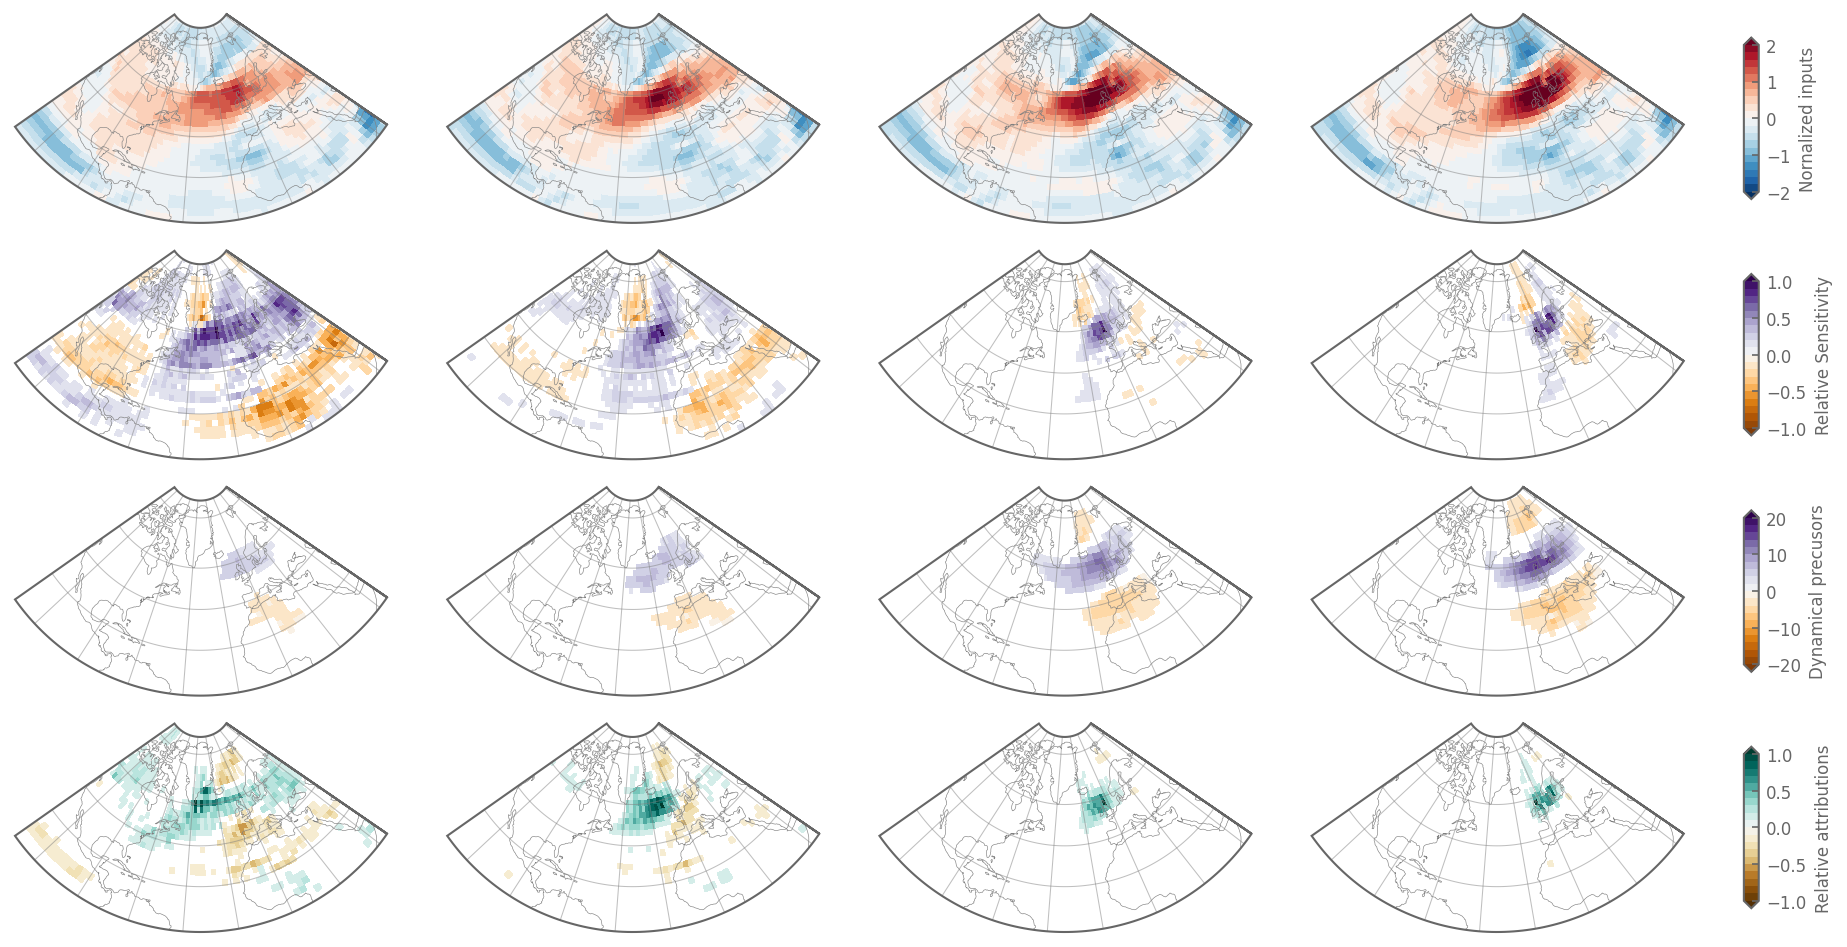

In [17]:
mosaic = [["F1","F2","F3","F4",'cF'],
        ["S1","S2","S3","S4",'cS'],
        ["J1","J2","J3","J4",'cJ'],
        ["A1","A2","A3","A4",'cA'],
        ]
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
map_kwargs = dict(projection=projection)
per_subplot_kw = {k:map_kwargs for k in np.array(mosaic).flatten() if 'c' not in k}

fig, axs = plt.subplot_mosaic(mosaic,
                               figsize=(15,8),
                                width_ratios = [10,10,10,10,.4],
                               per_subplot_kw=per_subplot_kw, gridspec_kw=dict(hspace=0.1))

level_fields = np.arange(-2,2.1,.2)
level_sensitivity = np.arange(-1,1.1,.1)
level_josh = np.arange(-20,20.1,2)
level_attributions = np.arange(-1,1.1,.1)

ds_winter = ds_main.where(ds_main.attribution_time.dt.season=='DJF').mean("attribution_time")
sens = (ds_winter.sensitivity/ds_winter.sensitivity.max(['longitude','latitude']))
attr = (ds_winter.attributions/ds_winter.attributions.max(['longitude','latitude']))
for k in range(1,5):
    ds_winter.fields.isel(timestep=k-1).plot(ax=axs[f'F{k}'], transform=ccrs.PlateCarree(), levels=level_fields, cbar_ax=axs['cF'], extend='both')
    sens.where(np.abs(sens)>0.1).isel(timestep=k-1).plot(ax=axs[f'S{k}'], transform=ccrs.PlateCarree(), levels=level_sensitivity, cmap='PuOr', cbar_ax=axs['cS'], extend='both')
    josh.isel(timestep=k-1).plot(ax=axs[f'J{k}'], transform=ccrs.PlateCarree(), levels=level_josh, cmap='PuOr', cbar_ax=axs['cJ'], extend='both',)
    attr.where(np.abs(attr)>0.1).isel(timestep=k-1).plot(ax=axs[f'A{k}'], transform=ccrs.PlateCarree(), levels=level_attributions,  cbar_ax=axs['cA'], extend='both', cmap='BrBG')

    for letter in ['A','F','S','J']:
        ax=axs[f'{letter}{k}']
        clean_map_ax(ax, boundaries = (-125, 50, 0, 85))
        ax.set_title('')
axs['cF'].yaxis.set_major_locator(plt.MultipleLocator(1))
axs['cS'].yaxis.set_major_locator(plt.MultipleLocator(.5))
axs['cJ'].yaxis.set_major_locator(plt.MultipleLocator(10))
axs['cA'].yaxis.set_major_locator(plt.MultipleLocator(.5))

axs['cF'].yaxis.set_minor_locator(plt.NullLocator())
axs['cS'].yaxis.set_minor_locator(plt.NullLocator())
axs['cJ'].yaxis.set_minor_locator(plt.NullLocator())
axs['cA'].yaxis.set_minor_locator(plt.NullLocator())

axs['cF'].set_ylabel("Nornalized inputs")
axs['cS'].set_ylabel("Relative Sensitivity")
axs['cA'].set_ylabel("Relative attributions")
axs['cJ'].set_ylabel("Dynamical precusors")

# for k in np.array(mosaic).flatten():
#     if 'c' not in k:
#         clean_map_ax(axs[k], boundaries = (-125, 50, 0, 85))
plt.savefig('plots/rosendal/all_maps_conv4.pdf')

# Compare with other models

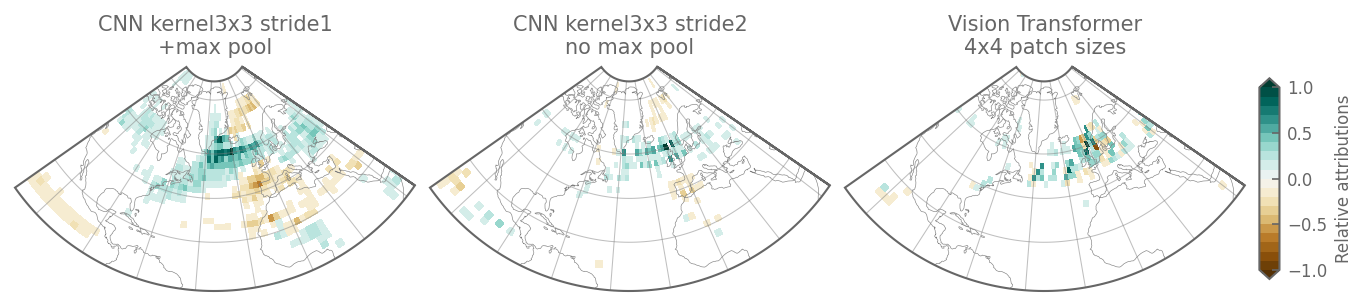

In [35]:
ds_test = ds_common.where(ds_common.attribution_time.dt.season=='DJF', drop=True).mean('attribution_time').isel(timestep=0)
ds_test=ds_test/ds_test.max(['longitude','latitude','var_name'])
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
plot = ds_test.where(np.abs(ds_test.attributions)>0.1).attributions.plot(col='model', subplot_kws=dict(projection=projection), transform=ccrs.PlateCarree(), 
                                 aspect=1.5, size=2,
                                 extend='both',
                                 cbar_kwargs=dict(shrink=.8, aspect=10, pad=0.01),
                                 levels=level_attributions, 
                                 cmap='BrBG')
titles = ['CNN kernel3x3 stride1\n+max pool', 'CNN kernel3x3 stride2\nno max pool','Vision Transformer\n4x4 patch sizes']
for k,ax in enumerate(plot.axs.flatten()):
    clean_map_ax(ax, boundaries = (-125, 50, 0, 85))
    ax.set_title(titles[k])
plot.cbar.ax.yaxis.set_major_locator(plt.MultipleLocator(.5))
plot.cbar.ax.yaxis.set_minor_locator(plt.NullLocator())
plot.cbar.ax.set_ylabel("Relative attributions")

plt.savefig('plots/rosendal/compare_with_other_nn.pdf')


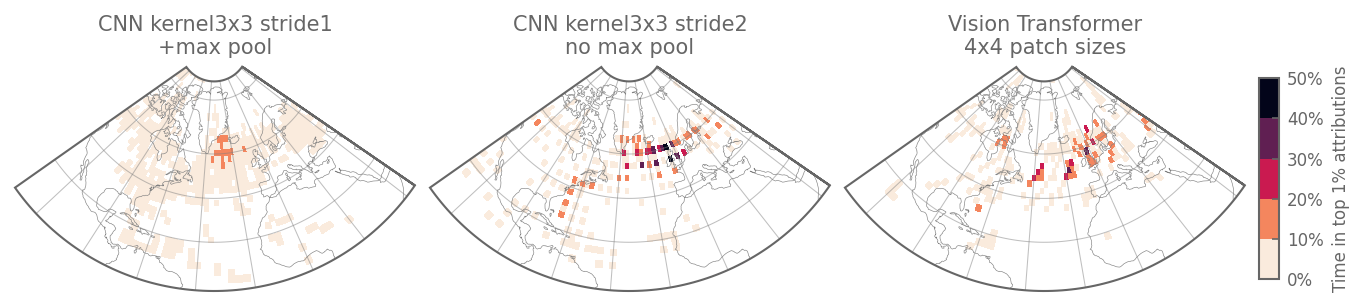

In [45]:
ds_ = ds_common.where(ds_common.stack(space=['latitude','longitude']).rank('space', pct=True).unstack()>0.99).count('attribution_time').attributions.isel(timestep=0,)
# ds_.where(ds_>0).plot(col='model', cmap='mako_r', levels=np.arange(0,60,10))

projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
plot = ds_.where(ds_>0).plot(col='model', subplot_kws=dict(projection=projection), transform=ccrs.PlateCarree(), 
                                 aspect=1.5, size=2,
                                 extend='neither',
                                 levels=np.arange(0,60,10),
                                 cbar_kwargs=dict(shrink=.8, aspect=10, pad=0.01),
                                 cmap='rocket_r')
titles = ['CNN kernel3x3 stride1\n+max pool', 'CNN kernel3x3 stride2\nno max pool','Vision Transformer\n4x4 patch sizes']
for k,ax in enumerate(plot.axs.flatten()):
    clean_map_ax(ax, boundaries = (-125, 50, 0, 85))
    ax.set_title(titles[k])
plot.cbar.ax.yaxis.set_major_locator(plt.MultipleLocator(10))
plot.cbar.ax.yaxis.set_major_formatter("{x:.0f}%")

# plot.cbar.ax.yaxis.set_minor_locator(plt.NullLocator())
plot.cbar.ax.set_ylabel("Time in top 1% attributions")
plt.savefig('plots/rosendal/compare_with_other_nn_top_pixels.pdf')


In [26]:
ds_test

NameError: name 'ds_test' is not defined

# individual events


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


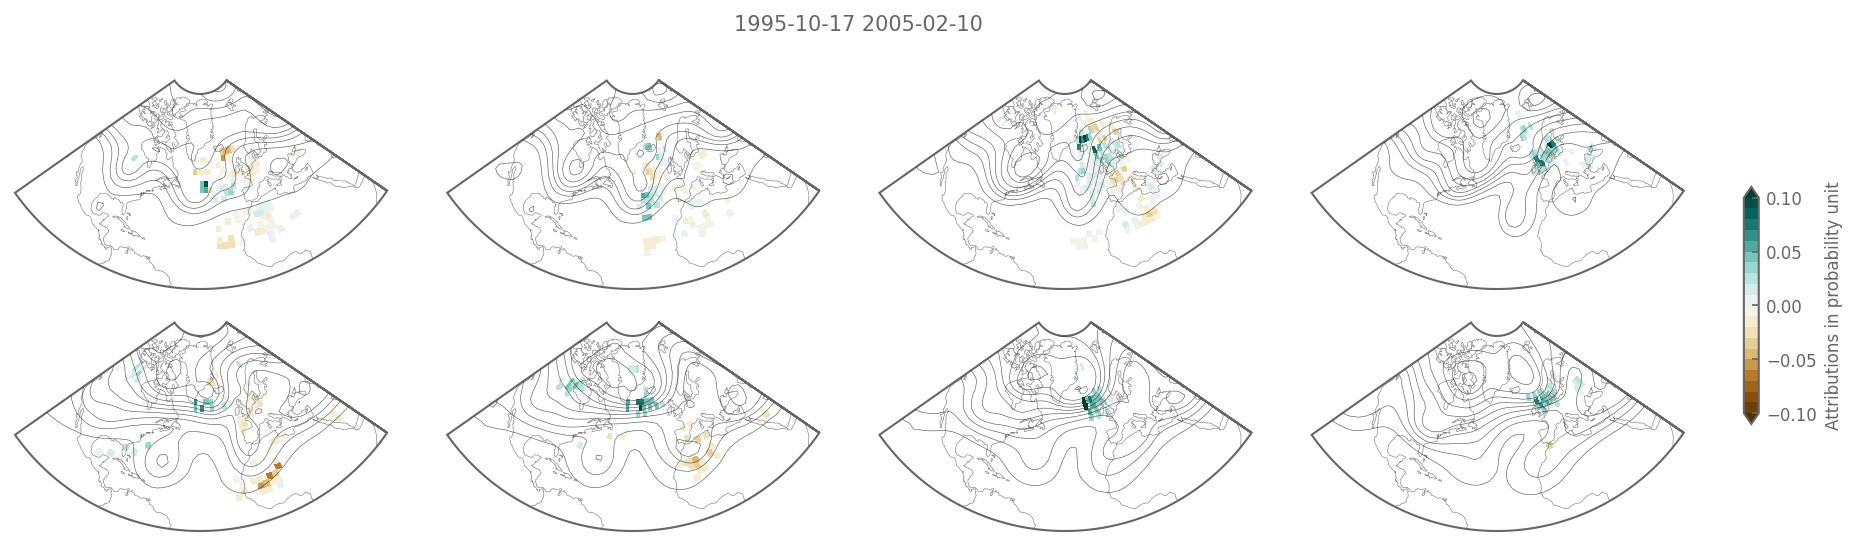

In [6]:
mosaic = [["F1","F2","F3","F4",'cF'],
          ["S1","S2","S3","S4",'cF'],
         ]
projection = ccrs.LambertConformal(central_longitude=-38.0, central_latitude=39.0)
map_kwargs = dict(projection=projection)
per_subplot_kw = {k:map_kwargs for k in np.array(mosaic).flatten() if 'c' not in k}

fig, axs = plt.subplot_mosaic(mosaic,
                               figsize=(15,4),
                                width_ratios = [10,10,10,10,.4],
                               per_subplot_kw=per_subplot_kw, gridspec_kw=dict(hspace=0.1))

level_fields = np.arange(-2,2.1,.2)
level_sensitivity = np.arange(-1,1.1,.1)
level_josh = np.arange(-20,20.1,2)
level_attributions = np.arange(-.1,.11,.01)
levels_z500 = np.arange(400,700,10)
times= ['1995-10-17','2005-02-10']

# ds_in = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_day_32x128.zarr").data_normed.sel(var_name = ['u850','v850']).to_dataset('var_name')
ds_in = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_day_32x128.zarr").sel(var_name = 'z500')
ds_in=(((ds_in.data_normed*ds_in.std_value)+ds_in.mean_value)/100)
# ds_in = ds_in.coarsen(longitude=2, latitude=2).mean()
ds_test = ds_main.sel(attribution_time=times)
ds_test_attributions = ds_test.attributions.where(np.abs(ds_test.sensitivity)>0.01)
level_fields_contour = np.arange(-3,3.1,1)
for t in range(ds_test.timestep.size):
    ds_test_attributions.squeeze().isel(timestep=t, attribution_time=0).plot(transform=ccrs.PlateCarree(),ax=axs[f"F{t+1}"], cbar_ax=axs['cF'], levels=level_attributions, cmap='BrBG', extend='both')
    ds_test_attributions.squeeze().isel(timestep=t, attribution_time=1).plot(transform=ccrs.PlateCarree(),ax=axs[f"S{t+1}"], cbar_ax=axs['cF'], levels=level_attributions, cmap='BrBG', extend='both')
    # ds_in.sel(time=slice(None, times[0])).isel(time=slice(-4,None)).isel(time=t).plot.quiver(x='longitude',y='latitude',u='u850', v='v850', transform=ccrs.PlateCarree(),ax=axs[f"F{t+1}"], add_guide=False)
    # ds_in.sel(time=slice(None, times[1])).isel(time=slice(-4,None)).isel(time=t).plot.quiver(x='longitude',y='latitude',u='u850', v='v850', transform=ccrs.PlateCarree(),ax=axs[f"S{t+1}"], add_guide=False)
    ds_in.sel(time=slice(None, times[0])).isel(time=slice(-4,None)).isel(time=t).squeeze().plot.contour(transform=ccrs.PlateCarree(),ax=axs[f"F{t+1}"], levels=levels_z500, alpha=.8,zorder=10, add_colorbar=False, colors='.2',linewidths=.3,)
    ds_in.sel(time=slice(None, times[1])).isel(time=slice(-4,None)).isel(time=t).squeeze().plot.contour(transform=ccrs.PlateCarree(),ax=axs[f"S{t+1}"], levels=levels_z500, alpha=.8,zorder=10, add_colorbar=False, colors='.2',linewidths=.3)
    clean_map_ax(axs[f"F{t+1}"], boundaries = (-125, 50, 0, 85), gl=False)
    clean_map_ax(axs[f"S{t+1}"], boundaries = (-125, 50, 0, 85), gl=False)
    axs[f"S{t+1}"].set_title('')
    axs[f"F{t+1}"].set_title('')

axs['cF'].yaxis.set_major_locator(plt.MultipleLocator(.05))
axs['cF'].yaxis.set_minor_locator(plt.NullLocator())
axs['cF'].set_ylabel("Attributions in probability unit")

fig.suptitle(' '.join(times), size=10, weight='normal')
plt.savefig('plots/rosendal/twocases_attributions.pdf')
